Итерация 1; Знак 1; значение ksi = 0.5
Итерация 2; Знак 1; значение ksi = 0.75
Итерация 3; Знак 1; значение ksi = 0.875
Итерация 4; Знак 1; значение ksi = 0.9375
Итерация 5; Знак 1; значение ksi = 0.96875
Итерация 6; Знак 1; значение ksi = 0.984375
Итерация 7; Знак 1; значение ksi = 0.9921875
Итерация 8; Знак 1; значение ksi = 0.99609375
Итерация 9; Знак 1; значение ksi = 0.998046875
Итерация 10; Знак 1; значение ksi = 0.9990234375
Итерация 11; Знак 1; значение ksi = 0.99951171875
Итерация 12; Знак 1; значение ksi = 0.999755859375
Итерация 13; Знак 1; значение ksi = 0.9998779296875
Итерация 14; Знак 1; значение ksi = 0.99993896484375
Итерация 15; Знак 1; значение ksi = 0.999969482421875
Итерация 16; Знак 1; значение ksi = 0.9999847412109375
Итерация 17; Знак 1; значение ksi = 0.99999237060546875
Итерация 18; Знак 1; значение ksi = 0.999996185302734375
Итерация 19; Знак 1; значение ksi = 0.9999980926513671875
Итерация 20; Знак -1; значение ksi = 0.99999904632568359375
Итерация 21; Знак 

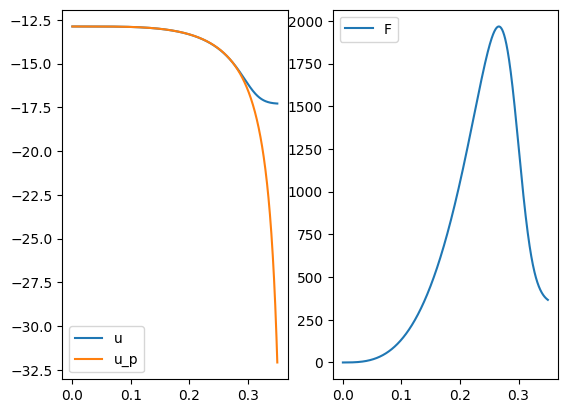

In [3]:
import math as m
import matplotlib.pyplot as plt
from decimal import Decimal, getcontext

# Установка точности для Decimal
getcontext().prec = 50

variant = int(input("Введите вариант задания (1-2): "))
while variant != 1 and variant != 2:
    variant = int(input("Введите вариант задания (1-2): "))

if variant == 1:
    table_in = [ [ Decimal(2000),  Decimal(8.2e-3)    ],
                  [ Decimal(3000),  Decimal(2.768e-2) ],
                  [ Decimal(4000),  Decimal(6.56e-2)  ],
                  [ Decimal(5000),  Decimal(1.281e-1) ],
                  [ Decimal(6000),  Decimal(2.214e-1) ],
                  [ Decimal(7000),  Decimal(3.516e-1) ],
                  [ Decimal(8000),  Decimal(5.248e-1) ],
                  [ Decimal(9000),  Decimal(7.472e-1) ],
                  [ Decimal(10000), Decimal(1.025)    ] ]
else:
    table_in = [ [ Decimal(2000),  Decimal(1.6)    ],
                  [ Decimal(3000),  Decimal(5.4)   ],
                  [ Decimal(4000),  Decimal(12.8)  ],
                  [ Decimal(5000),  Decimal(25)    ],
                  [ Decimal(6000),  Decimal(43.2)  ],
                  [ Decimal(7000),  Decimal(68.6)  ],
                  [ Decimal(8000),  Decimal(102.4) ],
                  [ Decimal(9000),  Decimal(145.8) ],
                  [ Decimal(10000), Decimal(200)   ] ]

table_with_replaces = [[Decimal(m.log(float(measure))) for measure in row] for row in table_in]

R0 = Decimal(0)
R = Decimal(0.35)
Tw = Decimal(2000)
T0 = Decimal(10000)
p = Decimal(4)
EPS = Decimal(1e-4)
c = Decimal(3 * 10 ** 10)

def rungeKuttaSystem(x0, u0, v0, h, n, f, phi):
    res_x, res_u, res_v = [], [], []
    x, u, v = x0, u0, v0
    for i in range(n):
        k1 = f(x, u, v)
        q1 = phi(x, u, v)
        k2 = f(x + h / 2, u + h / 2 * k1, v + h / 2 * q1)
        q2 = phi(x + h / 2, u + h / 2 * k1, v + h / 2 * q1)
        k3 = f(x + h / 2, u + h / 2 * k2, v + h / 2 *  q2)
        q3 = phi(x + h / 2, u + h / 2 * k2, v + h / 2 *  q2)
        k4 = f(x + h, u + h * k3, v + h * q3)
        q4 = phi(x + h, u + h * k3, v + h * q3)

        x += h
        u = u + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        v = v + h / 6 * (q1 + 2 * q2 + 2 * q3 + q4)
        res_u.append(u)
        res_v.append(v)
        res_x.append(x)

    return res_x, res_u, res_v

def calcT(r):
    return (Tw - T0) * (r / R) ** p + T0

def calcPlanca(r):
    return Decimal(3.084e-4) / (Decimal(m.exp(Decimal(4.799 * 10 ** 4) / calcT(r))) - Decimal(1))

def calcK(table, r):
    Tlog = Decimal(m.log(calcT(r)))
    klog = table[0][1] + (Tlog - table[0][0]) / (table[1][0] - table[0][0]) * (table[1][1] - table[0][1])
    return Decimal(m.exp(klog))

def fFunc(r, u, f):
    return (-Decimal(3)) * calcK(table_with_replaces, r) * f / c

def phiFunc(r, u, f):
    if r == 0:
        return c * calcK(table_with_replaces, r) * (calcPlanca(r) - u) / Decimal(2)
    return -(f / r) + c * calcK(table_with_replaces, r) * (calcPlanca(r) - u)

def calcSecondCond(u, v):
    return v[-1] - Decimal(0.39) * c * u[-1]

def sign(val):
    if abs(val) < EPS:
        return 0
    elif val < 0:
        return -1
    return 1

def shotMethodSolve():
    n = 1000
    ksi_l, ksi_r = Decimal(0), Decimal(1)
    u0_l, u0_r = ksi_l * calcPlanca(R0), ksi_r * calcPlanca(R0)
    F0 = Decimal(0)
    x_solve, u_l, f_l = rungeKuttaSystem(Decimal(0), u0_l, F0, (R - R0) / n, n, fFunc, phiFunc)
    u_r, f_r = rungeKuttaSystem(Decimal(0), u0_r, F0, (R - R0) / n, n, fFunc, phiFunc)[1:]
    l_sign = sign(calcSecondCond(u_l, f_l))
    r_sign = sign(calcSecondCond(u_r, f_r))
    u_solve, f_solve = [], []
    iter = 1
    while l_sign != r_sign:
        ksi_mid = (ksi_l + ksi_r) / Decimal(2)
        u0_mid = ksi_mid * calcPlanca(Decimal(0))
        u_mid, f_mid = rungeKuttaSystem(Decimal(0), u0_mid, F0, (R - R0) / n, n, fFunc, phiFunc)[1:]
        mid_sign = sign(calcSecondCond(u_mid, f_mid))
        print(f'Итерация {iter}; Знак {mid_sign}; значение ksi = {ksi_mid}')
        iter += 1
        if mid_sign == 0:
            u_solve = u_mid
            f_solve = f_mid
            break
        elif mid_sign == l_sign:
            ksi_l = ksi_mid
        else:
            ksi_r = ksi_mid

    u_p_solve = list(map(calcPlanca, x_solve))
    log_u_p_solve = [m.log(i) for i in u_p_solve]
    log_u_solve = [m.log(i) for i in u_solve]
    fig, ax = plt.subplots(1, 2)
    ax[0].plot(x_solve, log_u_solve, label="u")
    ax[0].plot(x_solve, log_u_p_solve, label="u_p")
    ax[0].legend()
    ax[1].plot(x_solve, f_solve, label="F")
    ax[1].legend()
    plt.show()

shotMethodSolve()

In [1]:
print(chr(sum(range(ord(min(str(not())))))))

ඞ
